# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberto a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno.  
    </b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-success">

<b>Comentário geral: </b> <a class="tocSkip"></a>

Parabéns pela conclusão do projeto, Iago! 🎉

A qualidade do seu trabalho está excelente e foi aprovado! Como pontos positivos, destaco: 
- Código eficiente e otimizado;
- Comentários que enriquecem a análise 
- Bom uso dos modelos

Para continuar se aprofundando em Processamento de Linguagem Natural (NLP), recomendo as seguintes referências:


- **Awesome NLP**  
  Lista curada de recursos sobre Processamento de Linguagem Natural, incluindo tutoriais, bibliotecas e materiais de estudo.  
  https://github.com/keon/awesome-nlp

- **Hugging Face Course**  
  Curso gratuito e acessível para iniciantes, cobrindo os fundamentos de NLP e modelos modernos baseados em transformers, com exemplos práticos.  
  https://huggingface.co/course




Te desejo sorte na sua jornada! 🍀


</div>

# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# a próxima linha fornece gráficos de melhor qualidade em telas HiDPI
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Carregar Dados

In [4]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
display(df_reviews.head())
print(df_reviews.shape)
print(df_reviews[['review', 'pos', 'ds_part']].isna().sum())
print(df_reviews['ds_part'].value_counts())
print(df_reviews['pos'].value_counts())

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


(47331, 17)
review     0
pos        0
ds_part    0
dtype: int64
train    23796
test     23535
Name: ds_part, dtype: int64
0    23715
1    23616
Name: pos, dtype: int64


<div class="alert alert-block alert-success">
  <strong>Comentário:</strong> <a class="tocSkip"></a><br><br>

Dados carregados corretamente.
</div>


## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

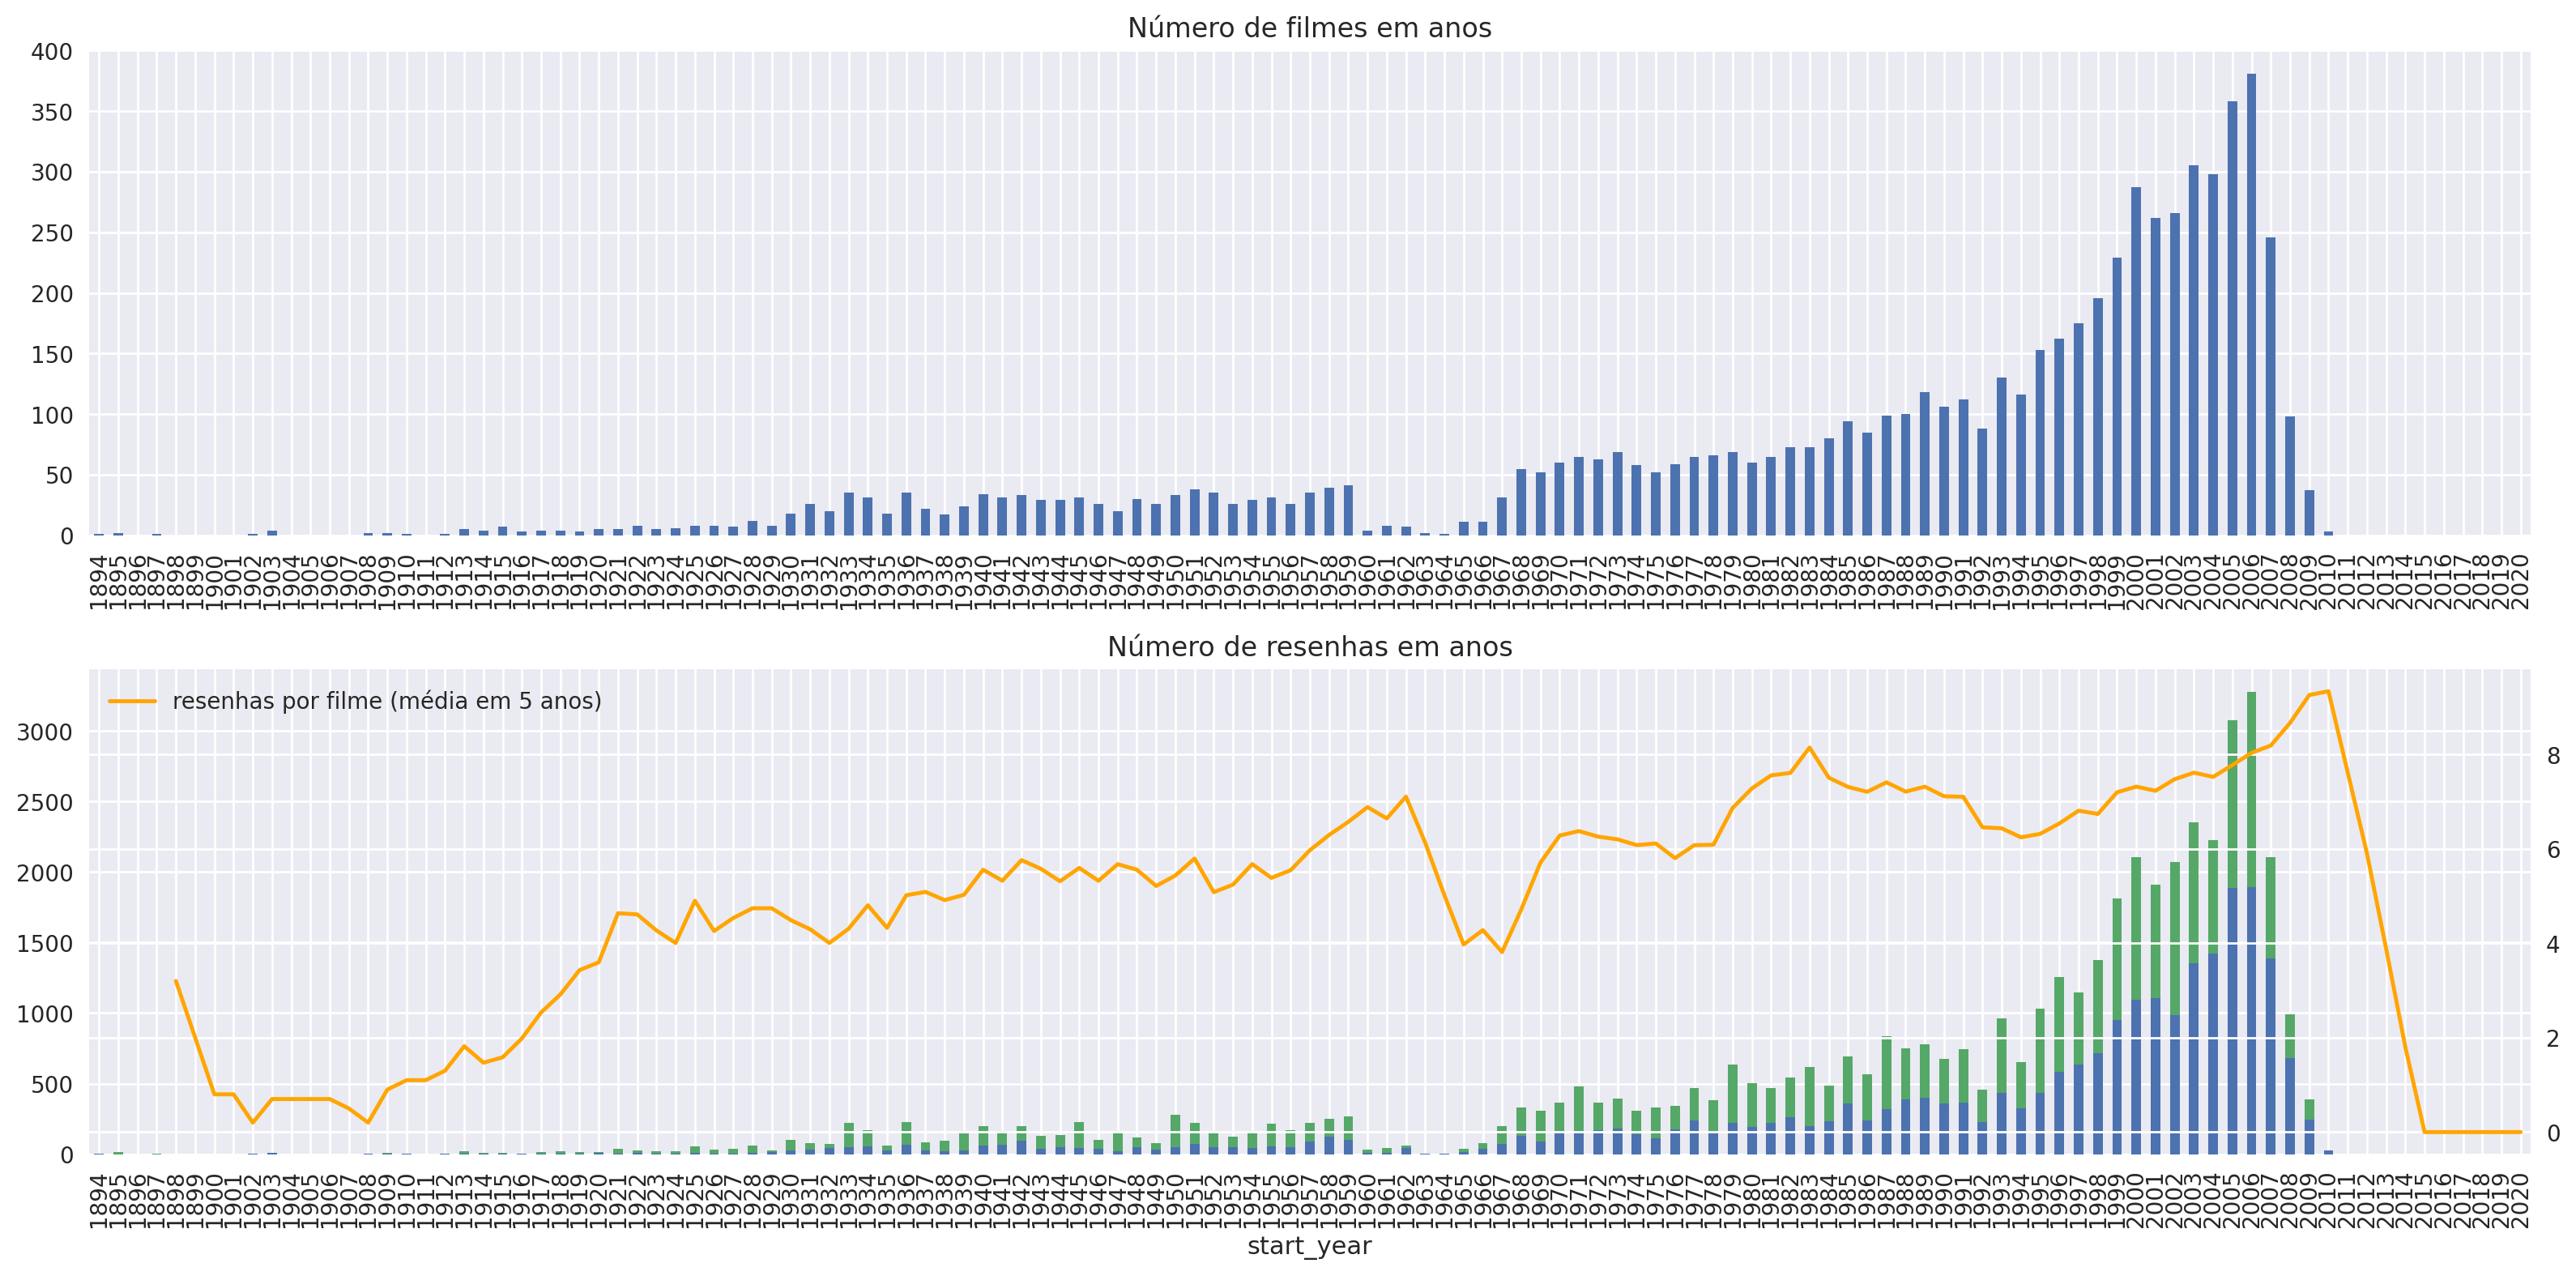

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes em anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas em anos')

fig.tight_layout()

Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel - só para saber como pode diferir da contagem exata)

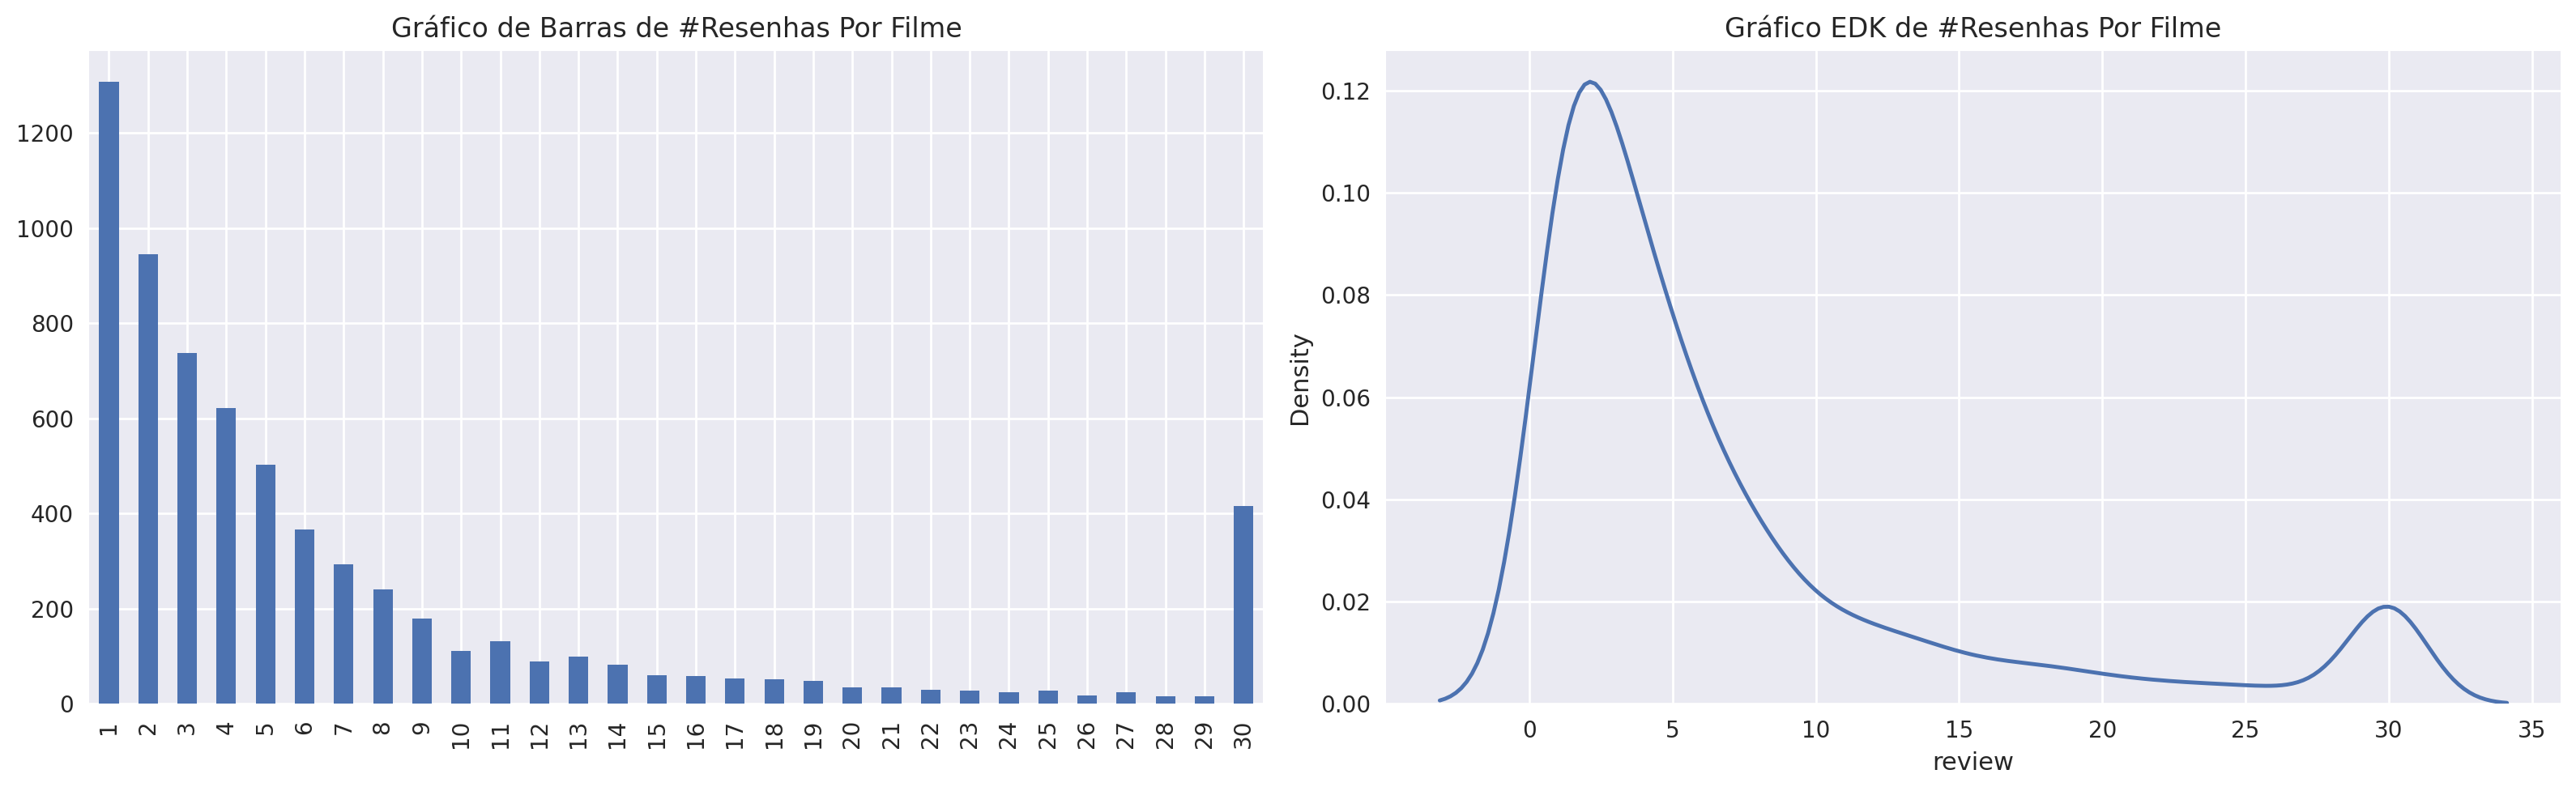

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de #Resenhas Por Filme')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico EDK de #Resenhas Por Filme')

fig.tight_layout()

In [8]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

<div class="alert alert-block alert-warning">
  <strong>Comentário:</strong> <a class="tocSkip"></a><br><br>
  Excelente trabalho na análise da distribuição das variáveis!  
  Se quiser verificar as porcentagens em vez dos valores absolutos, basta utilizar o argumento <code>normalize=True</code> com o método <code>value_counts()</code>.  
  <br><br>Exemplo:
  <pre><code>df['sua_coluna'].value_counts(normalize=True)</code></pre>
</div>


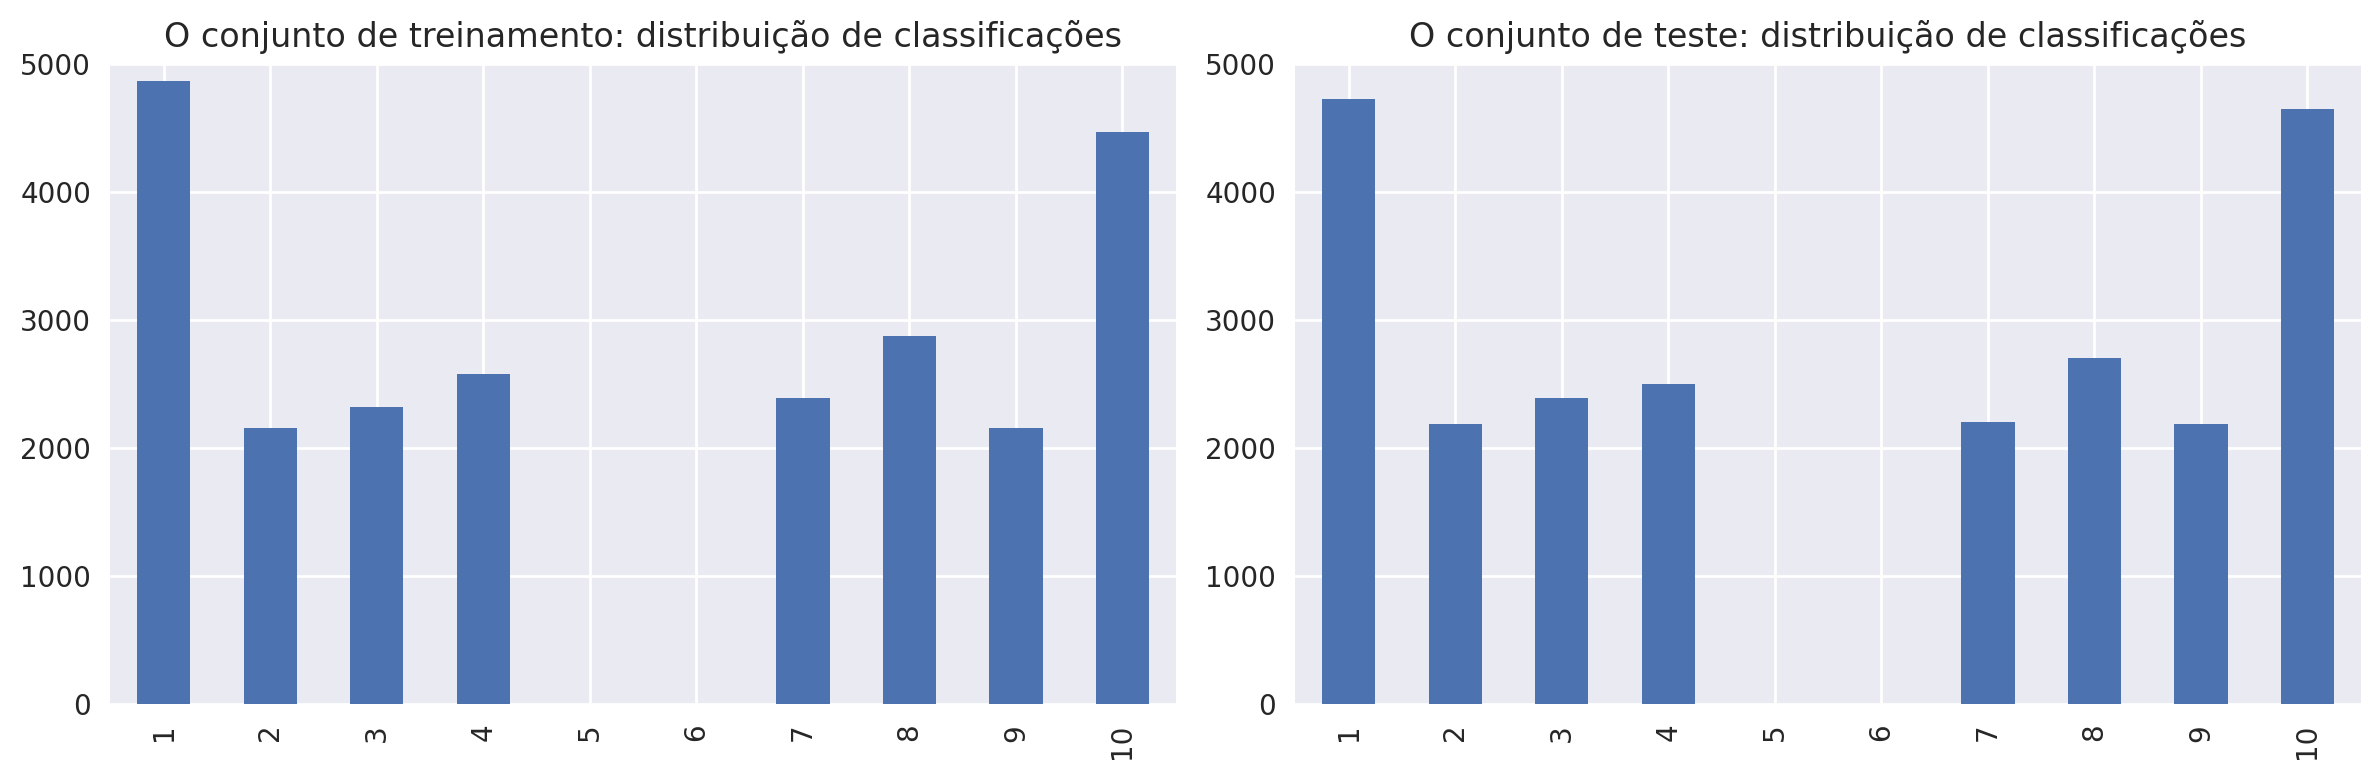

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()

Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

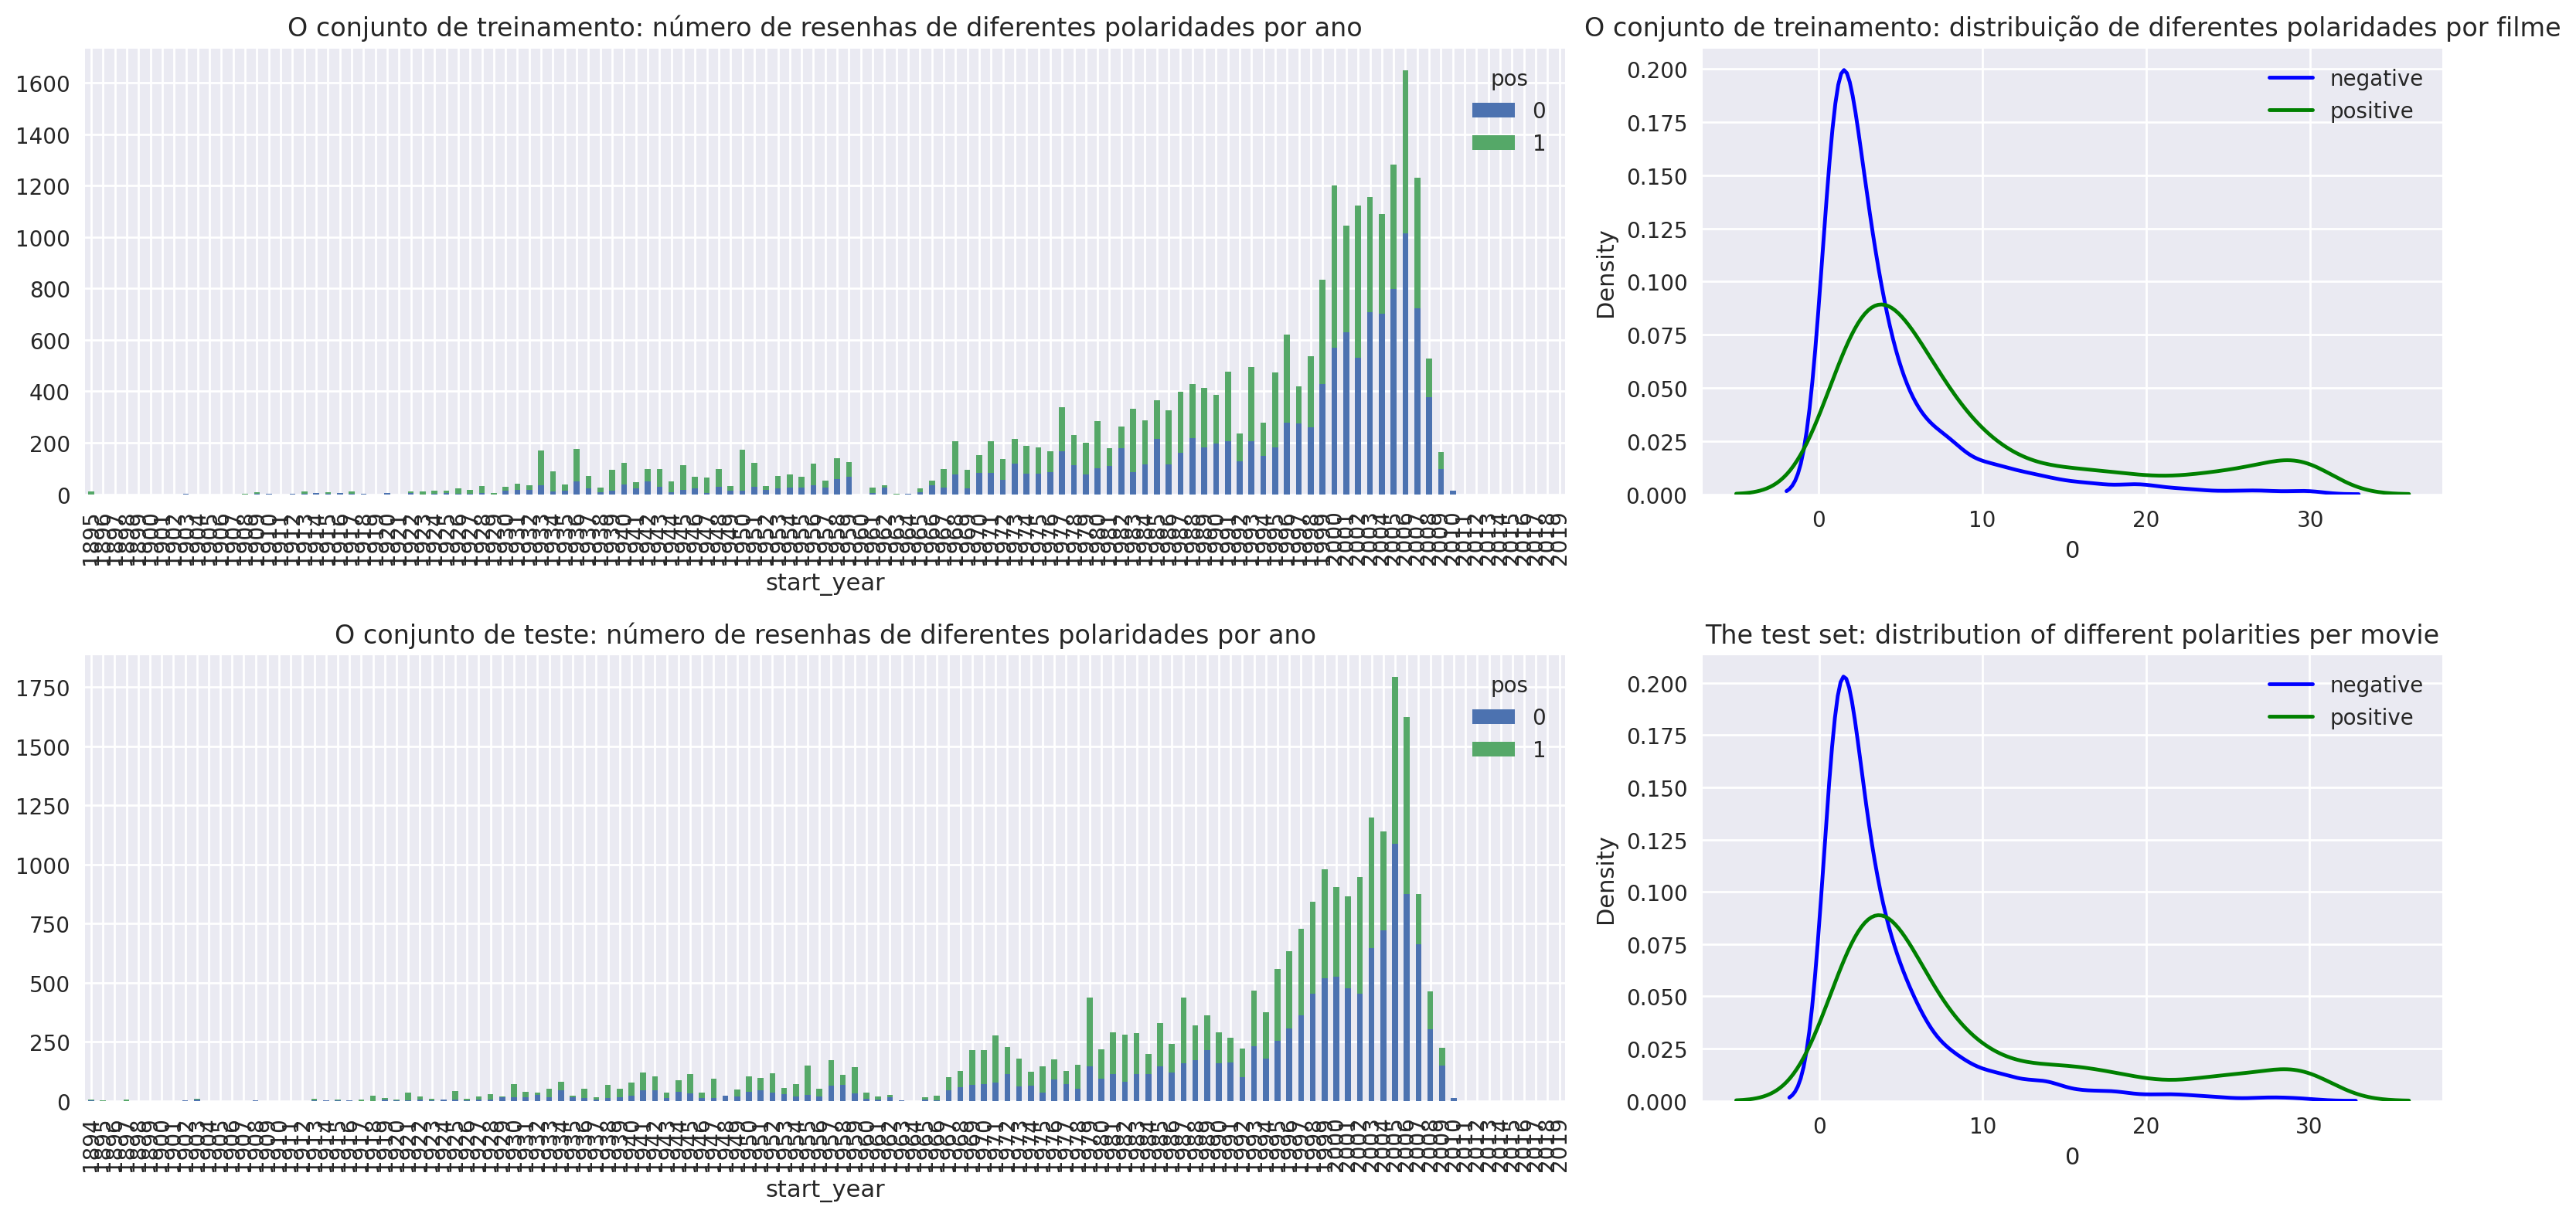

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

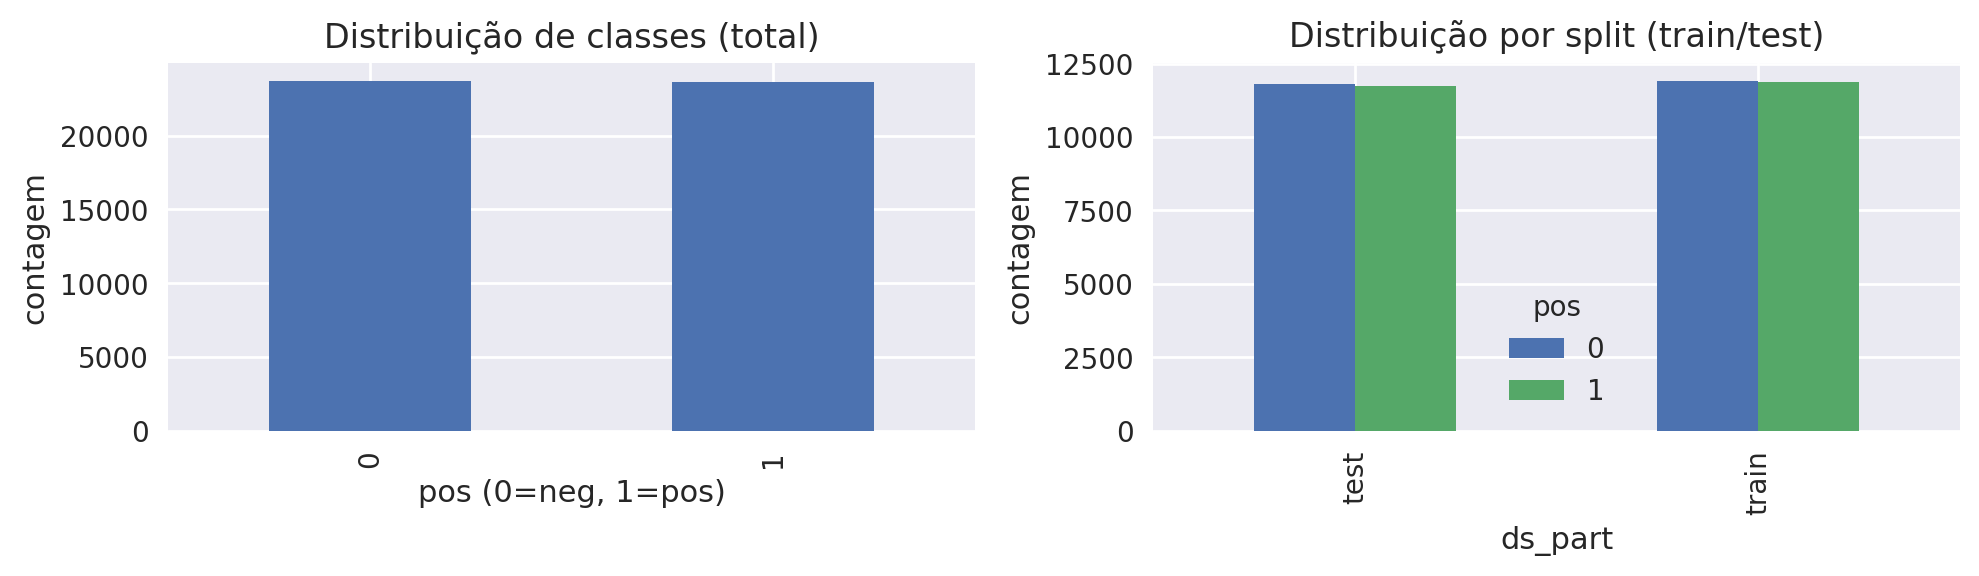

In [11]:
fig, axs = plt.subplots(1, 2, figsize=[10, 3])

df_reviews['pos'].value_counts().sort_index().plot(kind='bar', ax=axs[0])
axs[0].set_title('Distribuição de classes (total)')
axs[0].set_xlabel('pos (0=neg, 1=pos)')
axs[0].set_ylabel('contagem')

df_reviews.pivot_table(index='ds_part', columns='pos', values='review', aggfunc='count') \
          .plot(kind='bar', ax=axs[1])
axs[1].set_title('Distribuição por split (train/test)')
axs[1].set_xlabel('ds_part')
axs[1].set_ylabel('contagem')

plt.tight_layout()

## Conclusões da AED (Análise Exploratória)

### Visão geral do conjunto de dados
- O conjunto contém **47.331** resenhas e **18** colunas no total.
- As colunas críticas para o projeto (`review`, `pos`, `ds_part`) não apresentam valores ausentes.
- O dataset já vem dividido em partes:
  - **Treinamento (train): 23.796** resenhas  
  - **Teste (test): 23.535** resenhas  

### Distribuição das classes (desequilíbrio)
- A variável-alvo `pos` está **praticamente balanceada**:
  - **0 (negativa): 23.715**
  - **1 (positiva): 23.616**
- A diferença entre as classes é pequena (≈0,2%), portanto **não há desequilíbrio relevante** que justifique técnicas de reamostragem (oversampling/undersampling).
- Como consequência, a modelagem pode focar em:
  - uma boa representação do texto (ex.: **TF-IDF**),
  - modelos de classificação eficientes para texto,
  - e avaliação por **F1-score**, conforme exigência do projeto.

### Observações adicionais (contexto do dataset)
- A AED mostra que há variação na quantidade de filmes/resenhas ao longo dos anos e também heterogeneidade no número de resenhas por filme (muitos filmes com poucas resenhas e poucos filmes com muitas resenhas).
- Esses aspectos descrevem a composição do dataset, mas **não afetam diretamente a definição da tarefa**, que é classificar cada resenha individualmente como positiva/negativa.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Comentarios relevantes para analise de dados
</div>

## Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [12]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    eval_stats = {}

    fig, axs = plt.subplots(1, 3, figsize=[20, 6])

    for type_, features, target in (('train', train_features, train_target),
                                    ('test',  test_features,  test_target)):

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # Curva F1 por limiar
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba >= thr) for thr in f1_thresholds]

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)

        eval_stats[type_] = {
            'Acurácia': metrics.accuracy_score(target, pred_target),
            'F1': metrics.f1_score(target, pred_target),
            'APS': aps,
            'ROC AUC': roc_auc
        }

        color = 'blue' if type_ == 'train' else 'green'

        # --- Plot F1 ---
        ax = axs[0]
        max_idx = int(np.argmax(f1_scores))
        ax.plot(f1_thresholds, f1_scores, color=color,
                label=f'{type_}, max={f1_scores[max_idx]:.2f} @ {f1_thresholds[max_idx]:.2f}')
        for thr in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest = int(np.argmin(np.abs(f1_thresholds - thr)))
            ax.plot(f1_thresholds[closest], f1_scores[closest], marker='x')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title('Valor F1')

        # --- Plot ROC ---
        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{type_}, ROC AUC={roc_auc:.2f}')
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title('Curva ROC')

        # --- Plot PRC ---
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type_}, AP={aps:.2f}')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title('PRC')

    plt.tight_layout()

    df_eval_stats = pd.DataFrame(eval_stats).round(3)
    df_eval_stats = df_eval_stats.reindex(index=['Acurácia', 'F1', 'APS', 'ROC AUC'])
    display(df_eval_stats)

    return df_eval_stats

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

A função para avaliação dos modelos foi implementada corretamente!
</div>

## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [13]:
import re

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)      # remove <br />
    text = re.sub(r'[^a-z\s\']', ' ', text)     # mantém letras e apóstrofo
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_reviews['review_norm'] = df_reviews['review'].apply(normalize_text)

In [14]:
df_reviews[['review', 'review_norm']].head()

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teens in sing...
4,I'm totally agree with GarryJohal from Singapo...,i'm totally agree with garryjohal from singapo...


In [15]:
print("review_norm vazias:", (df_reviews['review_norm'].str.len() == 0).sum())
df_reviews['review_norm'].str.len().describe()

review_norm vazias: 0


count    47331.000000
mean      1252.223067
std        947.750657
min         30.000000
25%        670.000000
50%        928.000000
75%       1519.000000
max      13317.000000
Name: review_norm, dtype: float64

### Conclusão — Normalização do texto

- Criamos a coluna `review_norm` com o texto em minúsculas, removendo tags HTML (`<br />`), pontuação e dígitos, mantendo apenas letras e apóstrofos.
- A normalização não gerou textos vazios (`review_norm vazias: 0`).
- A partir daqui, usaremos `review_norm` como entrada para vetorização (ex.: TF-IDF) e treinamento dos modelos.

## Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [16]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

train_features = df_reviews_train['review_norm']
test_features = df_reviews_test['review_norm']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

print("Distribuição de classes (train):")
print(train_target.value_counts())

print("\nDistribuição de classes (test):")
print(test_target.value_counts())

(23796, 18)
(23535, 18)
Distribuição de classes (train):
0    11912
1    11884
Name: pos, dtype: int64

Distribuição de classes (test):
0    11803
1    11732
Name: pos, dtype: int64


## Trabalhando com modelos

### Modelo 0 - Constante

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

,train,test
Acurácia,0.501,0.502
F1,0.000,0.000
APS,0.499,0.498
ROC AUC,0.500,0.500


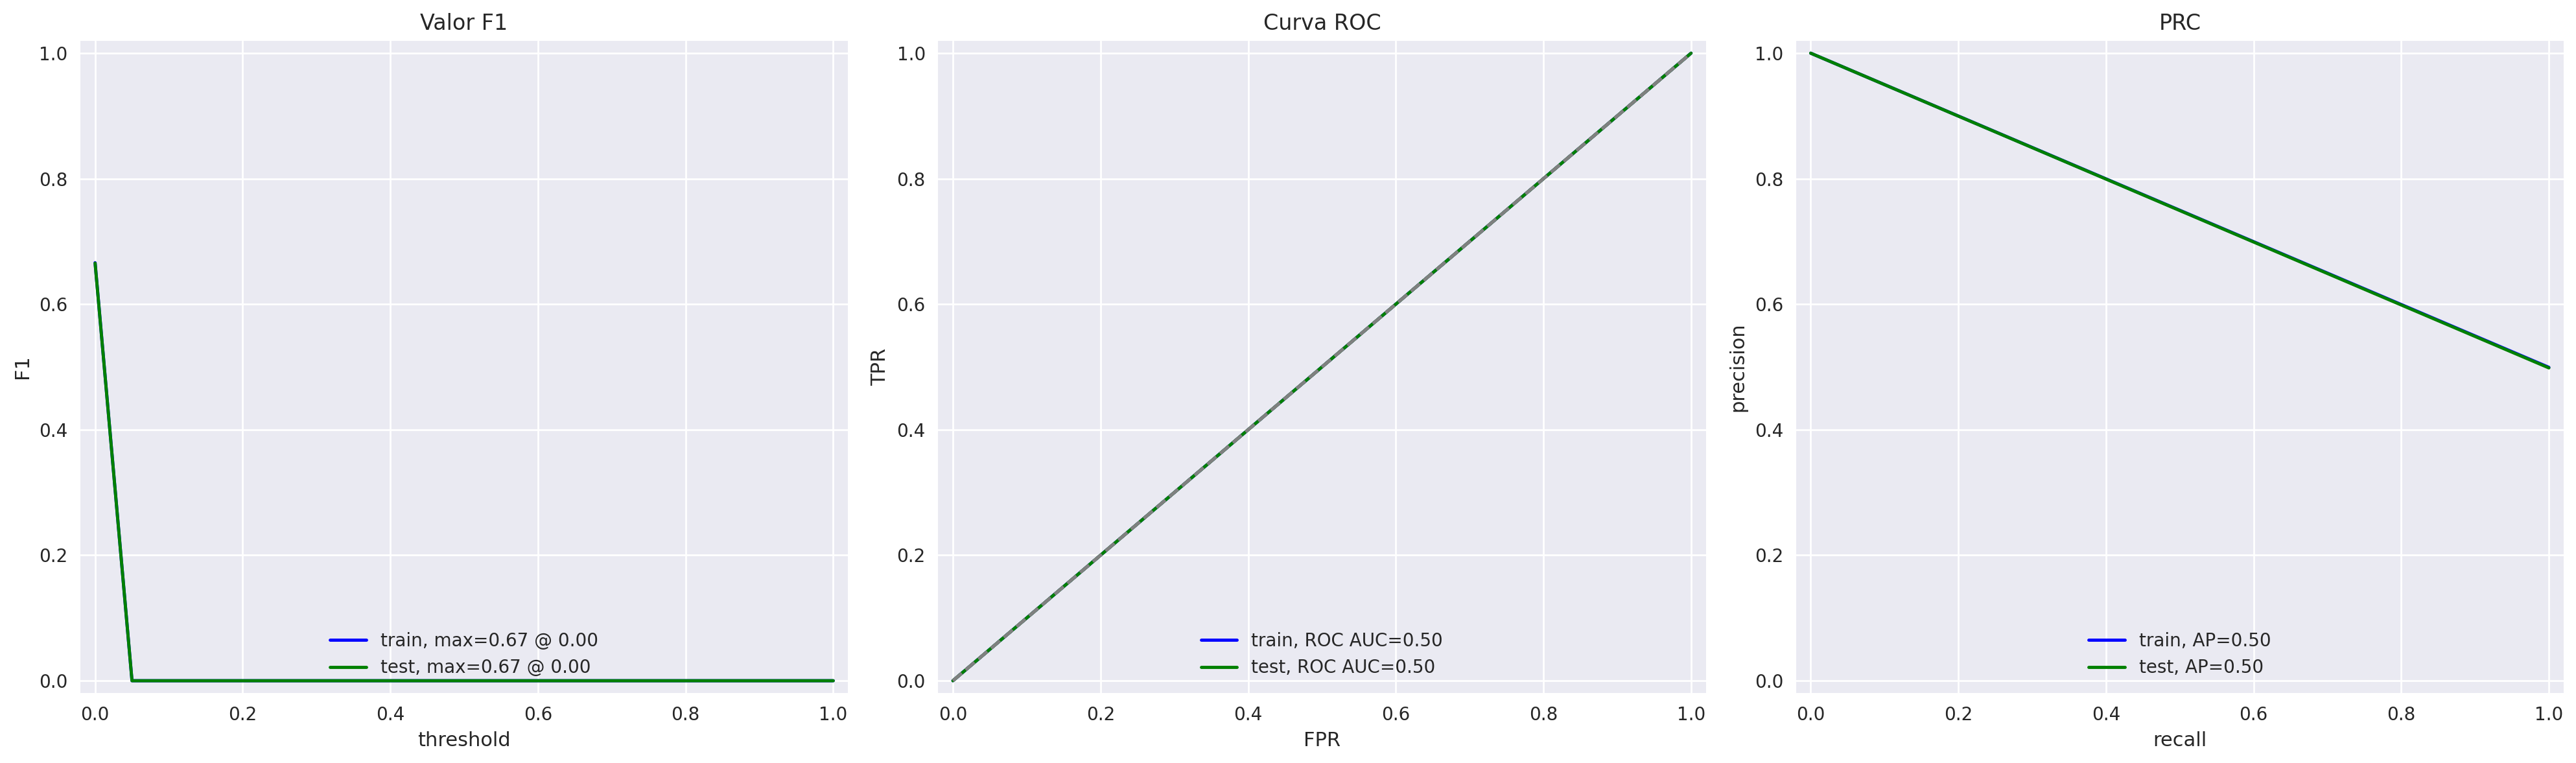

In [18]:
model_0 = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=2)),
    ('clf', DummyClassifier(strategy='most_frequent', random_state=123))
])

model_0.fit(train_features, train_target)
eval_0 = evaluate_model(model_0, train_features, train_target, test_features, test_target)

### Modelo 1 - NLTK, TF-IDF e Regressão Linear

TF-IDF

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

,train,test
Acurácia,0.991,0.891
F1,0.991,0.890
APS,0.999,0.954
ROC AUC,0.999,0.957


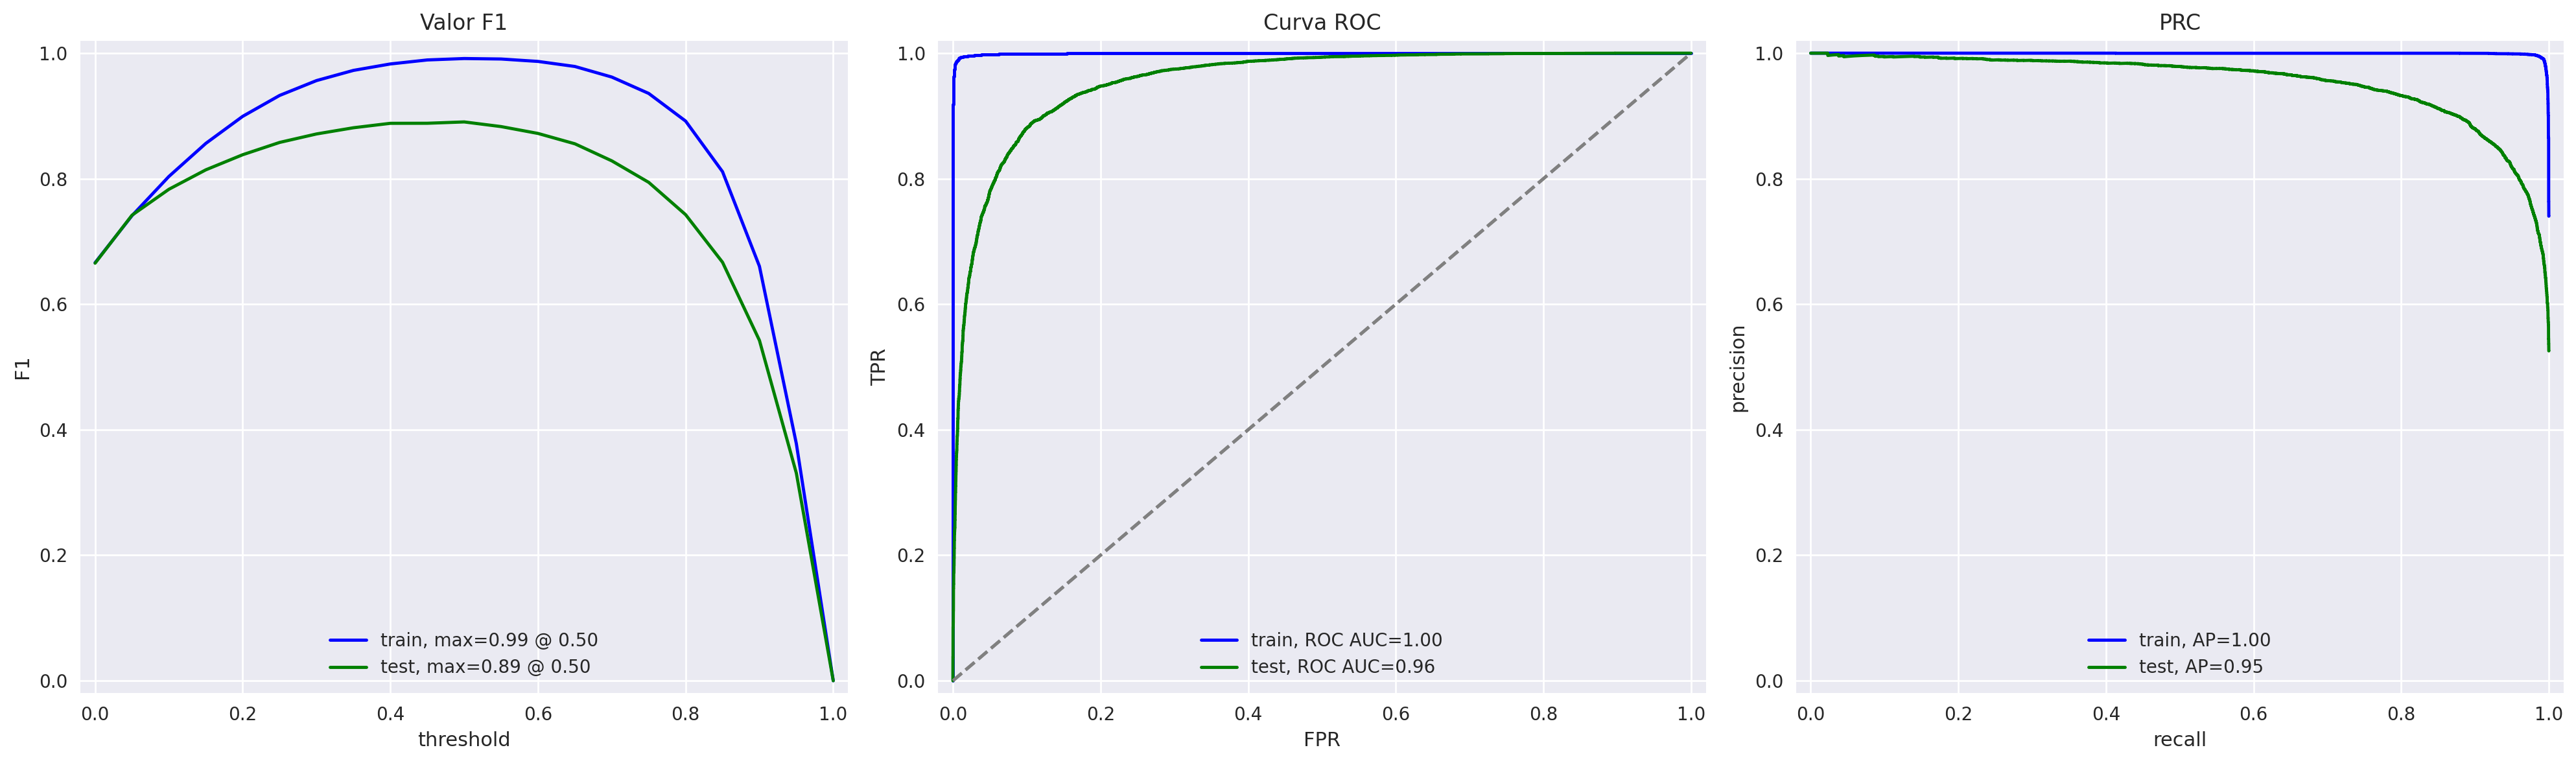

In [20]:
model_1 = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True,
        stop_words='english'
    )),
    ('clf', LogisticRegression(max_iter=1000, C=4, solver='liblinear'))
])

model_1.fit(train_features, train_target)
eval_1 = evaluate_model(model_1, train_features, train_target, test_features, test_target)

### Modelo 2 - TF-IDF (char_wb) e Regressão Logística

,train,test
Acurácia,0.958,0.885
F1,0.959,0.884
APS,0.992,0.952
ROC AUC,0.992,0.954


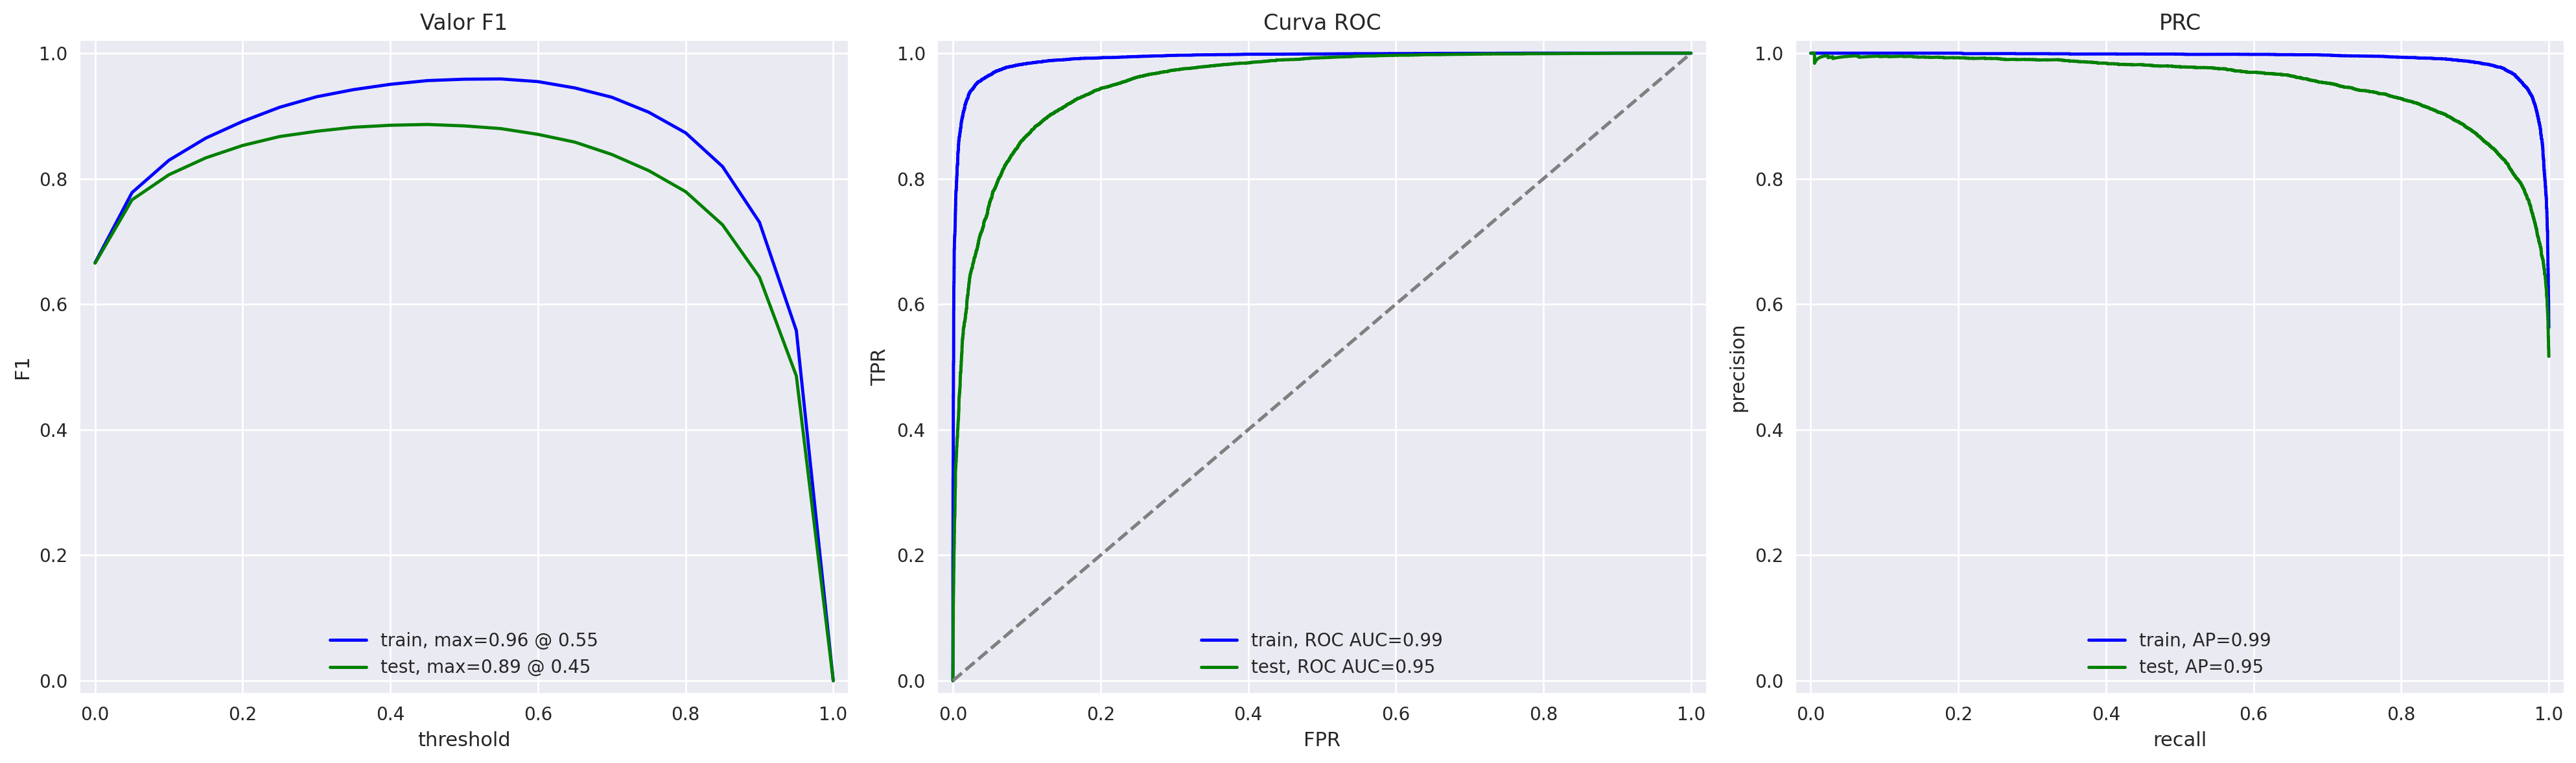

In [21]:
model_2 = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(max_iter=1000, C=4, solver='liblinear'))
])

model_2.fit(train_features, train_target)
eval_2 = evaluate_model(model_2, train_features, train_target, test_features, test_target)

### Modelo 3 - TF-IDF e ComplementNB

In [22]:
from sklearn.naive_bayes import ComplementNB

,train,test
Acurácia,0.965,0.868
F1,0.965,0.863
APS,0.995,0.941
ROC AUC,0.995,0.944


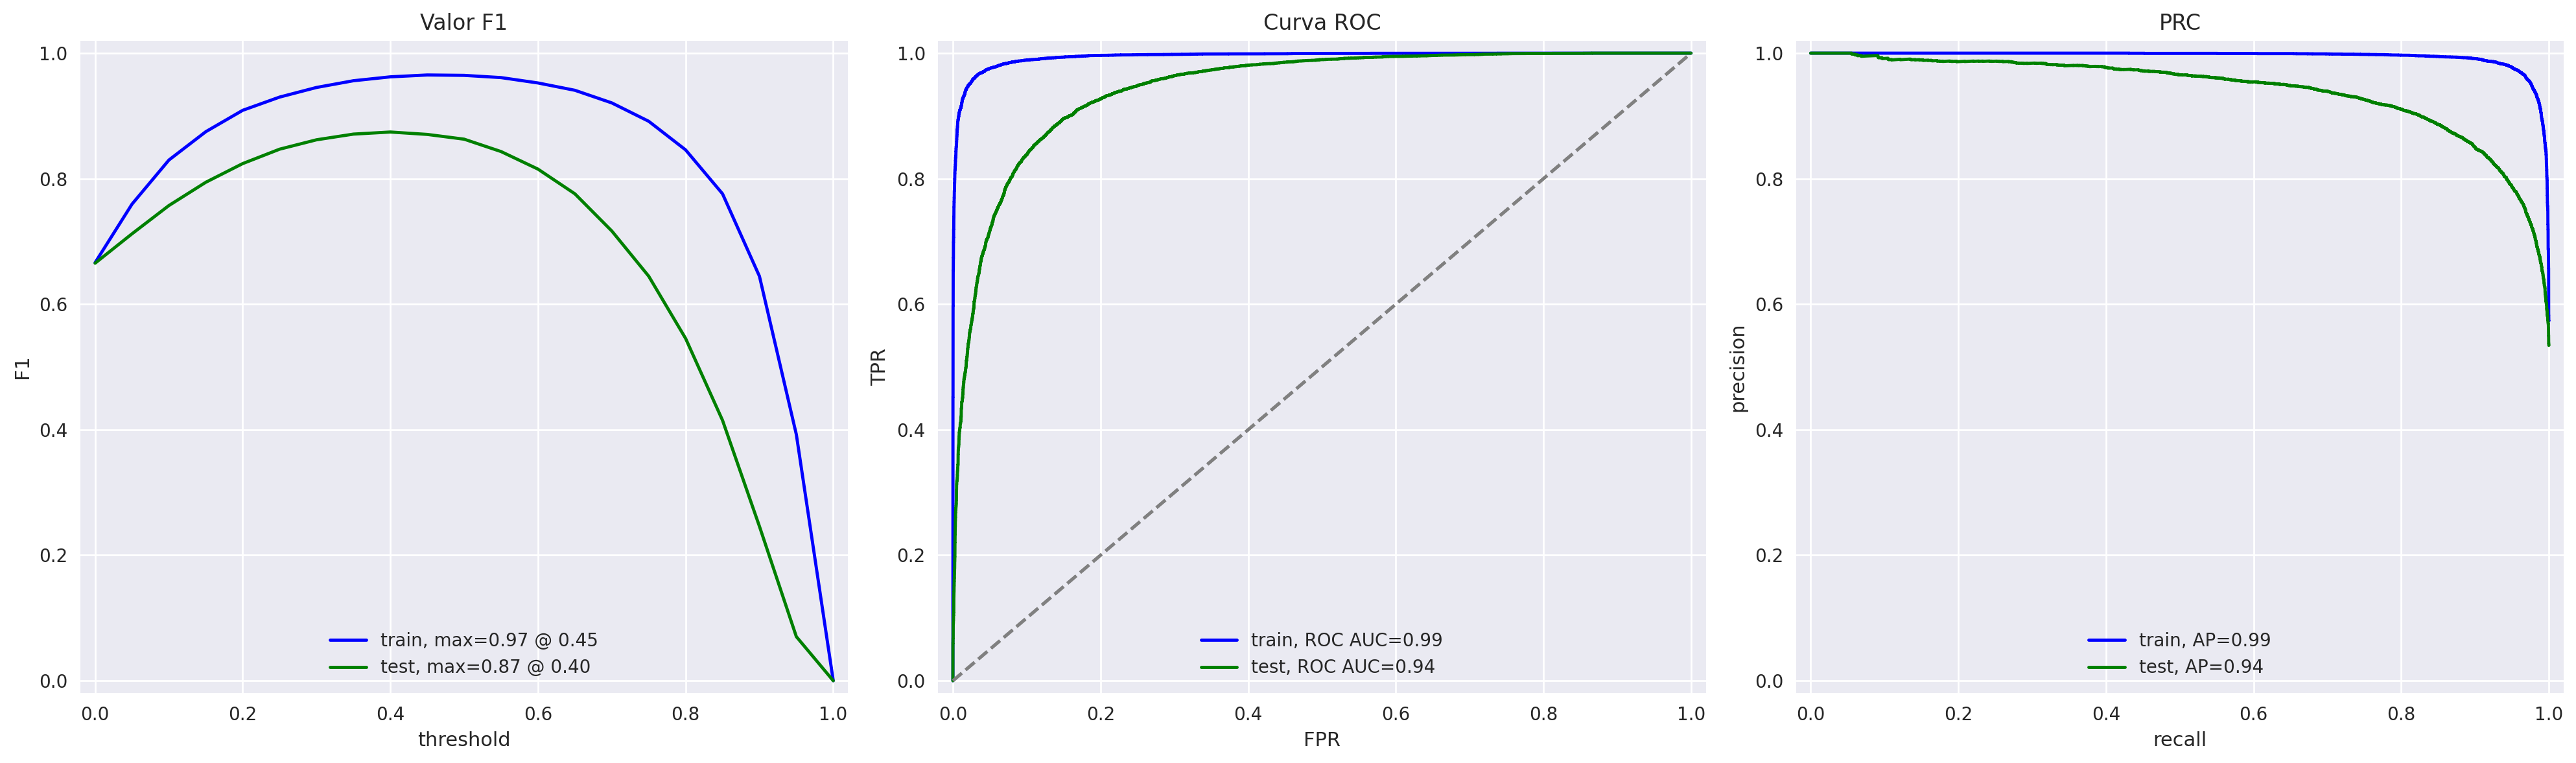

In [23]:
model_3 = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2
    )),
    ('clf', ComplementNB(alpha=0.5))
])

model_3.fit(train_features, train_target)
eval_3 = evaluate_model(model_3, train_features, train_target, test_features, test_target)

### Comparação dos modelos (no conjunto de teste)

- **Modelo 1 (TF-IDF word 1–2 + Regressão Logística)**: F1 ≈ **0,890**
- **Modelo 2 (TF-IDF char_wb 3–5 + Regressão Logística)**: F1 ≈ **0,884**
- **Modelo 3 (TF-IDF word 1–2 + ComplementNB)**: F1 ≈ **0,863**
- **Baseline (Dummy)**: F1 ≈ **0,000** (prevê sempre a classe majoritária)

**Conclusão:** todos os modelos principais atingiram o requisito **F1 ≥ 0,85** no teste.  
O melhor desempenho foi obtido pelo **Modelo 1**, indicando que TF-IDF com n-grams de palavras (1–2) + Regressão Logística captura bem os padrões de polaridade do IMDB.

<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>


 Caso tenha interesse em como rodar o modelo BERT no google colab (por conta da capacidade computacional), veja um exemplo aqui: [Modelo BERT no Google Colab](https://colab.research.google.com/drive/16BWcgSoSQ-vBuGfPFTURjLgLBYWruua7?usp=sharing).


</div>

## Minhas Resenhas

In [24]:
my_reviews = pd.DataFrame([
    "I absolutely loved this movie. Great acting and a beautiful story.",
    "One of the best films I've seen this year. Highly recommended.",
    "The plot was weak and the characters were annoying. I regret watching it.",
    "Terrible pacing, boring dialogue, and a completely forgettable ending.",
    "It had some good moments, but overall it felt average and too long.",
    "Not bad, but not great either — a decent watch if you have time."
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)
my_reviews

,review,review_norm
0,I absolutely loved this movie. Great acting an...,i absolutely loved this movie great acting and...
1,One of the best films I've seen this year. Hig...,one of the best films i've seen this year high...
2,The plot was weak and the characters were anno...,the plot was weak and the characters were anno...
3,"Terrible pacing, boring dialogue, and a comple...",terrible pacing boring dialogue and a complete...
4,"It had some good moments, but overall it felt ...",it had some good moments but overall it felt a...
5,"Not bad, but not great either — a decent watch...",not bad but not great either a decent watch if...


### Modelos

In [25]:
models = {
    'Baseline (Dummy)': model_0,
    'LR (word 1-2)': model_1,
    'LR (char_wb 3-5)': model_2,
    'ComplementNB': model_3
}

texts = my_reviews['review_norm']

for name, m in models.items():
    probs = m.predict_proba(texts)[:, 1]
    print(f'\n{name}')
    for p, raw in zip(probs, my_reviews['review']):
        print(f'{p:.2f}: {raw}')


Baseline (Dummy)
0.00: I absolutely loved this movie. Great acting and a beautiful story.
0.00: One of the best films I've seen this year. Highly recommended.
0.00: The plot was weak and the characters were annoying. I regret watching it.
0.00: Terrible pacing, boring dialogue, and a completely forgettable ending.
0.00: It had some good moments, but overall it felt average and too long.
0.00: Not bad, but not great either — a decent watch if you have time.

LR (word 1-2)
0.99: I absolutely loved this movie. Great acting and a beautiful story.
0.99: One of the best films I've seen this year. Highly recommended.
0.03: The plot was weak and the characters were annoying. I regret watching it.
0.01: Terrible pacing, boring dialogue, and a completely forgettable ending.
0.56: It had some good moments, but overall it felt average and too long.
0.47: Not bad, but not great either — a decent watch if you have time.

LR (char_wb 3-5)
0.99: I absolutely loved this movie. Great acting and a beaut

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Correto! O estudante:
- Aplicou corretamente o `TFIDF` separadamente nos conjuntos de treino e teste
- Fez o pré-processamento removendo `stopwords`
- Usou `lemmatizer` processamento de texto

</div>

### Por que usar resenhas em inglês nas previsões manuais?

O conjunto IMDB utilizado no treinamento e teste é composto majoritariamente por **textos em inglês**.  
Como os modelos deste projeto usam **TF-IDF**, eles dependem diretamente do vocabulário observado durante o treinamento (palavras e n-grams).

Se eu escrevesse resenhas em português, ocorreria um forte **deslocamento de domínio (domain shift)** por idioma:
- muitas palavras do português não existiriam no vocabulário aprendido pelo vetorizador,
- a representação vetorial ficaria “pobre” (muitos zeros),
- e as previsões tenderiam a ser instáveis ou enviesadas.

Por isso, as resenhas manuais foram escritas em inglês para manter a mesma distribuição linguística do dataset e tornar a comparação entre modelos mais justa.

### Comparação: desempenho no teste vs previsões em resenhas manuais

Os resultados no conjunto de teste medem o desempenho do modelo em uma amostra grande e representativa do dataset (IMDB), fornecendo uma estimativa robusta de generalização.

Já as previsões em “minhas resenhas” têm características diferentes:
- **Tamanho amostral muito pequeno** (apenas algumas frases), logo não há estabilidade estatística.
- **Estilo e vocabulário diferentes** do conjunto real: frases curtas, diretas e com palavras fortemente polarizadas (“loved”, “terrible”, “boring”).
- As resenhas manuais podem ser **mais fáceis** do que exemplos reais ambíguos do IMDB, inflando a “sensação” de acerto.
- Modelos podem divergir em casos “mistos” (ex.: “Not bad, but not great”), porque:
  - TF-IDF de palavras (1–2) tende a capturar melhor negações/expressões completas (“not great”),
  - TF-IDF de caracteres (char_wb) é mais robusto a variações ortográficas, mas pode ser menos interpretável semanticamente,
  - Naive Bayes pode ser mais sensível a palavras individuais frequentes e menos eficiente em certas construções.

Por isso, a comparação principal deve ser feita usando o **conjunto de teste** (métrica F1), enquanto as resenhas manuais servem como validação qualitativa e interpretação do comportamento dos modelos.

## Conclusões finais

### Objetivo do projeto
O objetivo foi treinar um modelo capaz de classificar resenhas do IMDB como **negativas (0)** ou **positivas (1)**, atingindo **F1 ≥ 0,85** no conjunto de teste.

### Preparação e análise exploratória
- Os dados foram carregados corretamente e já continham a divisão **train/test** (`ds_part`).
- O alvo (`pos`) mostrou-se **praticamente balanceado**, portanto não foi necessário aplicar reamostragem.
- Foi realizada normalização do texto (`review_norm`) para padronizar a entrada antes da vetorização.

### Modelagem e resultados
Foram treinados e avaliados diferentes modelos baseados em TF-IDF:

- **Baseline (Dummy)**: desempenho equivalente ao acaso (F1 ≈ 0), servindo como referência mínima.
- **TF-IDF (word 1–2) + Regressão Logística (Modelo 1)**: melhor desempenho no teste (**F1 ≈ 0,890**).
- **TF-IDF (char_wb 3–5) + Regressão Logística (Modelo 2)**: também atingiu o requisito (**F1 ≈ 0,884**).
- **TF-IDF (word 1–2) + ComplementNB (Modelo 3)**: atingiu o requisito com menor margem (**F1 ≈ 0,863**).

Assim, o requisito de qualidade (**F1 ≥ 0,85**) foi atendido com mais de um modelo, e o **Modelo 1** foi selecionado como o principal candidato por apresentar o melhor desempenho no conjunto de teste.

### Avaliação qualitativa com resenhas manuais
As resenhas manuais foram escritas em **inglês** para evitar deslocamento de domínio por idioma, já que o treinamento/teste foi realizado em textos em inglês.  
Os modelos demonstraram comportamento consistente em frases claramente positivas/negativas, enquanto divergências ocorreram em frases ambíguas — o que é esperado, dado que a avaliação qualitativa usa poucas amostras e não substitui a métrica no conjunto de teste.

In [26]:
results = pd.DataFrame({
    'Modelo': ['Baseline (Dummy)', 'LR (word 1-2)', 'LR (char_wb 3-5)', 'ComplementNB'],
    'F1 (test)': [eval_0.loc['F1', 'test'], eval_1.loc['F1', 'test'], eval_2.loc['F1', 'test'], eval_3.loc['F1', 'test']],
    'ROC AUC (test)': [eval_0.loc['ROC AUC', 'test'], eval_1.loc['ROC AUC', 'test'], eval_2.loc['ROC AUC', 'test'], eval_3.loc['ROC AUC', 'test']],
    'APS (test)': [eval_0.loc['APS', 'test'], eval_1.loc['APS', 'test'], eval_2.loc['APS', 'test'], eval_3.loc['APS', 'test']],
}).sort_values('F1 (test)', ascending=False)

display(results)

,Modelo,F1 (test),ROC AUC (test),APS (test)
1,LR (word 1-2),0.890,0.957,0.954
2,LR (char_wb 3-5),0.884,0.954,0.952
3,ComplementNB,0.863,0.944,0.941
0,Baseline (Dummy),0.000,0.500,0.498


# Checklist

- [x]  O caderno foi aberto
- [x]  Os dados de texto são carregados e pré-processados para vetorização
- [x]  Os dados de texto são transformados em vetores
- [x]  Os modelos são treinados e testados
- [x]  O limiar da métrica foi atingido
- [x]  Todas as células de código estão organizadas na ordem de sua execução
- [x]  Todas as células de código podem ser executadas sem erros
- [x]  Há conclusões 